# North Atlantic Hurricane Spatial Patterns Since 1970

This notebook analyzes the spatial patterns of North Atlantic hurricanes using the NOAA IBTrACS hurricane track dataset.

My part of the group project focuses on hurricane track maps, geographic density, and comparisons among selected active hurricane seasons.

The main question for this notebook is:

How have the spatial patterns of North Atlantic hurricanes changed since 1970, and where do hurricanes most frequently occur?

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (12,6)

url = "https://www.ncei.noaa.gov/data/international-best-track-archive-for-climate-stewardship-ibtracs/v04r00/access/csv/ibtracs.ALL.list.v04r00.csv"

df = pd.read_csv(
    url,
    parse_dates=["ISO_TIME"],
    usecols=range(12),
    skiprows=[1],
    na_values=[" ","NOT_NAMED"],
    keep_default_na=False,
    dtype={"NAME":str}
)

In [10]:
df = df.rename(
    columns={
        "WMO_WIND":"WIND",
        "WMO_PRES":"PRES"
    }
)

df_na = df[
    (df["BASIN"]=="NA") &
    (df["SEASON"]>=1970)
].copy()

print("Number of datapoints:",len(df_na))
print("Unique storms:",df_na["SID"].nunique())

Number of datapoints: 48154
Unique storms: 914


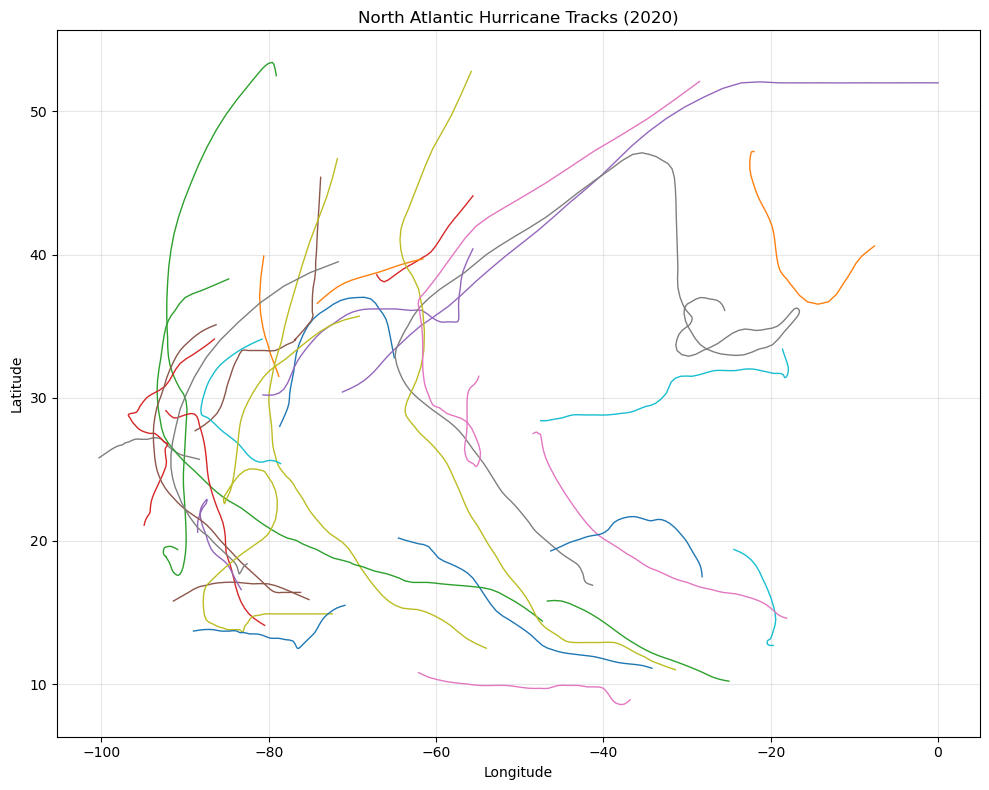

In [11]:
year = 2020

storm2020 = df_na[df_na["SEASON"]==year]

fig,ax=plt.subplots(figsize=(10,8))

for sid,storm in storm2020.groupby("SID"):

    ax.plot(
        storm["LON"],
        storm["LAT"],
        linewidth=1
    )

ax.set_title("North Atlantic Hurricane Tracks (2020)")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.grid(True,alpha=0.3)

plt.tight_layout()
plt.show()

In [21]:
#Figure 1 shows the tracks of all North Atlantic tropical cyclones during the 2020 hurricane season. The map illustrates the paths followed by storms and highlights the wide geographic coverage of this exceptionally active season.

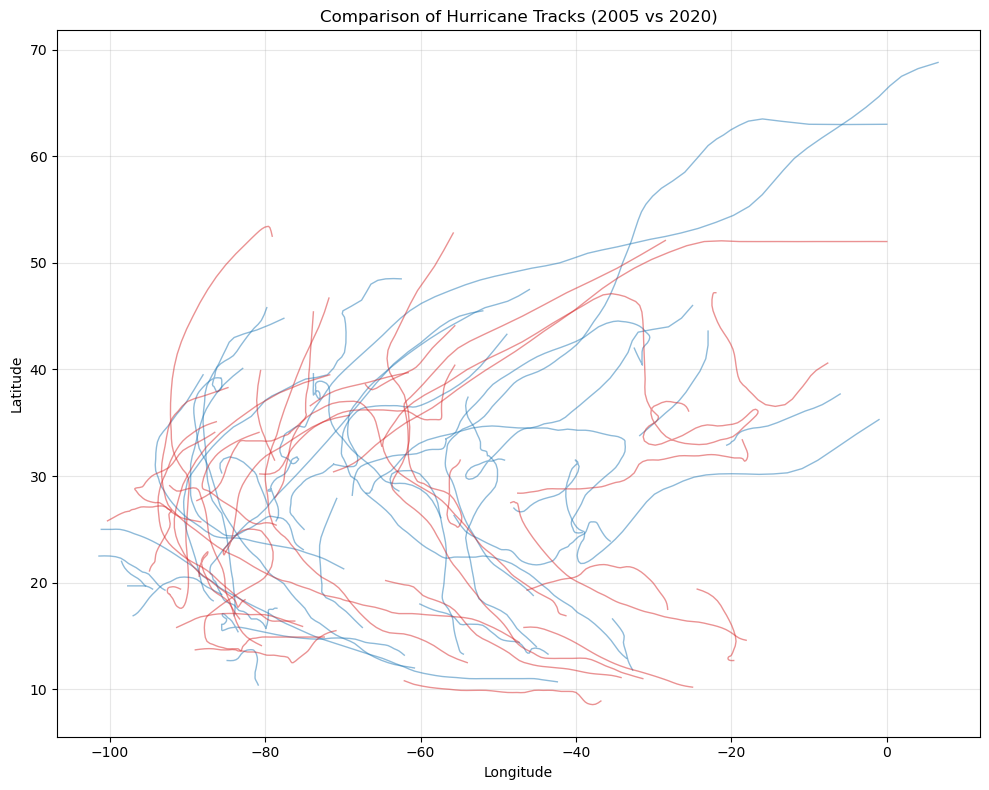

In [14]:
years=[2005,2020]

fig,ax=plt.subplots(figsize=(10,8))

colors=["tab:blue","tab:red"]

for y,c in zip(years,colors):

    temp=df_na[df_na["SEASON"]==y]

    for sid,storm in temp.groupby("SID"):

        ax.plot(
            storm["LON"],
            storm["LAT"],
            color=c,
            alpha=0.5,
            linewidth=1
        )

ax.set_title("Comparison of Hurricane Tracks (2005 vs 2020)")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.grid(True,alpha=0.3)

plt.tight_layout()
plt.show()

In [19]:
#Figure 2 compares hurricane tracks during two exceptionally active hurricane seasons, 2005 and 2020. Both seasons exhibit numerous storm tracks across the tropical Atlantic, Caribbean Sea, and Gulf of Mexico.

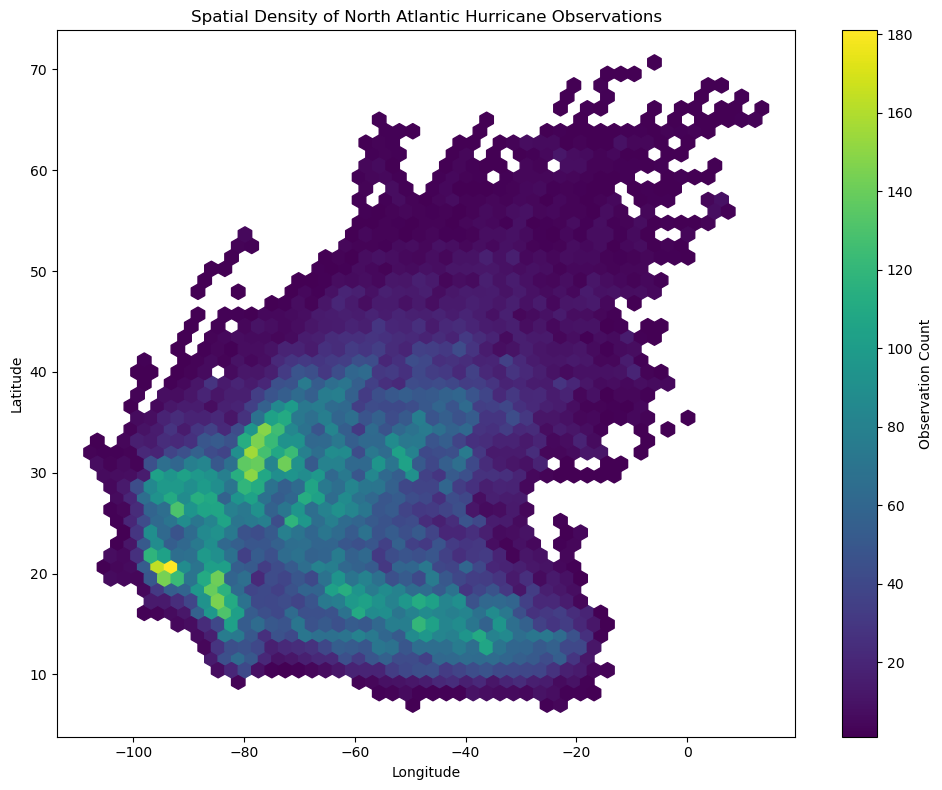

In [15]:
fig,ax=plt.subplots(figsize=(10,8))

hb=ax.hexbin(
    df_na["LON"],
    df_na["LAT"],
    gridsize=50,
    mincnt=1
)

plt.colorbar(hb,label="Observation Count")

ax.set_title("Spatial Density of North Atlantic Hurricane Observations")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

plt.tight_layout()
plt.show()

In [18]:
#The spatial density map highlights the regions where hurricane observations are most concentrated. The highest densities occur in the tropical Atlantic, Caribbean Sea, and Gulf of Mexico, reflecting the primary development and tracking regions of North Atlantic tropical cyclones.

In [16]:
lon_bin=(df_na["LON"]//5)*5
lat_bin=(df_na["LAT"]//5)*5

density=(
    df_na
    .groupby([lat_bin,lon_bin])
    .size()
    .sort_values(ascending=False)
)

print(density.head(10))

LAT   LON  
30.0  -80.0    1199
      -75.0     986
15.0  -85.0     912
25.0  -95.0     905
      -80.0     892
      -90.0     875
      -70.0     831
20.0  -95.0     771
      -90.0     766
15.0  -60.0     764
dtype: int64


In [17]:
#The highest-density grid cells correspond to regions where storms frequently develop or pass, providing a quantitative summary of the geographic hotspots identified in the density map.

## Conclusion

This notebook examined the spatial patterns of North Atlantic hurricanes since 1970 using the NOAA IBTrACS hurricane track dataset. The hurricane track maps illustrate the movement of storms during active seasons, while the comparison between 2005 and 2020 highlights similarities in storm pathways during two exceptionally active years. The spatial density map identifies the tropical Atlantic, Caribbean Sea, and Gulf of Mexico as the primary regions of hurricane activity.

Overall, the analysis shows that although hurricane activity varies substantially between years, the major geographic pathways remain relatively consistent across decades.